# Develop quick stuff

For temporary/quick stuff to be developed

In [ ]:
import os
import sys

base_path = os.path.abspath("./..")
if base_path not in sys.path:
    sys.path.append(base_path)

from IPython.display import display, Markdown
import torch

from berebasl.simulation.credit_data_simulation import CreditDataGenerator, CreditData

grid_path = '../berebasl/data/simulations/mnar_grid_hyp_testing'
base_sim = 'bias_0_0_corr_0_0'

init_objs_path = os.path.join(grid_path, base_sim, 'initial_simulation_objects_cv_mnar.pt')
dgp_base: CreditDataGenerator = torch.load(init_objs_path, map_location='cpu', weights_only=False)["data_generator"]

In [ ]:
from matplotlib.collections import LineCollection
from matplotlib.lines import Line2D
from matplotlib.colors import to_rgb
from typing import Any, Dict, List, Tuple, Union
from experiments.acceptance_loop_cv_based_MNAR import EXPECTATION_TYPES, METRIC_CATEGORIES, THRESHOLD_BASIS, REAL_PERFORMANCE_TYPES
from matplotlib import pyplot as plt

from numpy import ndarray

def extract_objs_from_sim_dir(grid_path: str, sim_dir: str, device: torch.device = torch.device('cpu')):
    sim_results_path = os.path.join(grid_path, sim_dir, 'simulation_results_cv_mnar.pt')
    init_objs_path = os.path.join(grid_path, sim_dir, 'initial_simulation_objects_cv_mnar.pt')
    perf_bayes_stats_path = os.path.join(grid_path, sim_dir, "stats_perf_bayes.pt")

    assert all([os.path.exists(p) for p in (sim_results_path, init_objs_path, perf_bayes_stats_path)])
    
    sim_results = torch.load(sim_results_path, map_location='cpu', weights_only=False)
    init_objs = torch.load(init_objs_path, map_location='cpu', weights_only=False)
    perf_bayes_stats = torch.load(perf_bayes_stats_path, map_location='cpu', weights_only=False)

    data_generator: CreditDataGenerator = init_objs['data_generator'].to(device)
    stats = sim_results['stats']
    ## Extract the sample sizes as a tensor
    sample_sizes = torch.tensor(stats['sample_size'], device=device)
    ## stack the present lists of tensors
    stats = {
        k : (torch.stack(v) if isinstance(v[0], torch.Tensor) else torch.tensor(v)).to(device) 
        for k, v in stats.items()
    }
    perf_bayes_stats = {k: v.clone() for k, v in perf_bayes_stats.items()}

    corr_pos = sim_dir.find("_corr")
    bias_prop = float(sim_dir[len("bias_"):corr_pos].replace("_", "."))
    corr = float(sim_dir[corr_pos + len("_corr_"):].replace("_", "."))


    return {
            "Description" : f"$\\sigma_{{h, m}} = {corr}$, $\\mathbb{{P}}(bias) = {bias_prop}$",
            "corr_to_hidden" : corr,
            "bias_prop" : bias_prop,
            "stats" : stats,
            "perf_bayes_stats" : perf_bayes_stats,
            "alternative_accepted" : sim_results["alternative_accepted"],
            "sample_sizes" : sample_sizes,
            "credit_data" : sim_results["credit_data"].to(device),
            "data_generator" : data_generator,
            "k_folds" : init_objs["configs"]["k_folds"],
            "cv_count" : init_objs["configs"]["cv_count"]
        }

def gen_lines_colors_and_main(
        stat: torch.Tensor, 
        sample_sizes: torch.Tensor, 
        base_color: Tuple[float],
        main_lbl: str, 
        alpha_dict: Dict[int, float], 
        lines: List[ndarray] = None, 
        colors: List[Tuple[float]] = None,
        sort_stat: bool = True
    )-> Tuple[List[ndarray], List[Tuple[float]], Dict[str, Union[List[ndarray], Dict[str, Any]]]]:
    stat_dim = stat.dim()
    if stat_dim == 0:
        raise ValueError("stat should have at least one dim")
    
    if lines is None:
        lines = []
    if colors is None:
        colors = []
    
    if stat_dim > 1:
        if sort_stat:
            stat = stat.sort(dim=0).values
        broadcasted_sizes = sample_sizes.expand_as(stat) # [k, cv, gen]

        stat_with_sizes = torch.stack([broadcasted_sizes, stat], dim=-1).flatten(0,-3)

        lines.extend(
            [s.detach().cpu().numpy() 
             for s in stat_with_sizes]
        )
        
        colors.extend([base_color + (alpha_dict.get(stat_dim, 0.5),)] * stat_with_sizes.size(0))

        return gen_lines_colors_and_main(
            stat.nanmean(dim=0),
            sample_sizes,
            base_color,
            main_lbl,
            alpha_dict,
            lines,
            colors
        )
    
    main_dict = {
            "args" : [t.detach().cpu().numpy() for t in (sample_sizes, stat)],
            "kwargs" : {
                "color" : base_color + (alpha_dict.get(stat_dim, 1),),
                "linewidth" : 1.2,
                "label" : main_lbl
            }
        }
    
    return lines, colors, main_dict

def linetypes_labels_and_colors_for_exp_real_plot(
        only_related_exp: bool = True
):
    linetypes = ["exp", "exp_bayes"] + REAL_PERFORMANCE_TYPES + ["real_bayes"]
    labels_linetypes = {
        "exp" : "Expectation (logit)",
        "exp_bayes" : "Expectation (Perf. Bayes)",
        "biased_acc" : "Real. on Biased Accepts",
        "unbiased_acc" : "Real. on Unbiased Accepts",
        "unbiased_future" : "Real. on Unbiased Future Observations",
        "real_bayes" : "Real. Perf. Bayes on related Exp",
    }
    if only_related_exp:
        for k in ['biased_acc', 'unbiased_acc', 'unbiased_future']:
            labels_linetypes[k] = "Realized (logit)"
        labels_linetypes["real_bayes"] = "Realized (Bayes)"

    colors = plt.rcParams["axes.prop_cycle"].by_key()["color"]
    colors_map = {}
    if only_related_exp:
        idx_colors = 0
        for e in linetypes:
            colors_map[e] = to_rgb(colors[idx_colors])
            if e in ["exp", "exp_bayes", "unbiased_future"]:
                idx_colors += 1
    else:
        colors_map = {e : to_rgb(c) for e, c in zip(linetypes, colors[:len(linetypes)])}

    return linetypes, labels_linetypes, colors_map

def get_acc_defaults_counts_per_round(sim_objs) -> Dict[str, torch.Tensor]:
    all_threshold_lbls = [t+'_'+m for m in METRIC_CATEGORIES for t in THRESHOLD_BASIS]
    acc_flags: Dict[str, torch.Tensor] = {k : v.clone() for k, v in sim_objs['alternative_accepted'].items()}
    lbl_acc_flag_in_data = set(all_threshold_lbls) - set(acc_flags.keys())
    assert len(lbl_acc_flag_in_data) == 1
    lbl_acc_flag_in_data = next(lbl_acc_flag_in_data.__iter__())

    credit_data: CreditData = sim_objs["credit_data"]
    acc_flags[lbl_acc_flag_in_data] = credit_data.accepted.clone()

    rounds = credit_data.gen_round
    G = credit_data.last_gen_round + 1 # Count rounds

    boolean_def_flag = credit_data.default_flag.to(bool)

    return {
        k : v.new_zeros((G,), dtype=torch.int32).scatter_add_(
            dim=-1,
            index=rounds,
            src=(v & boolean_def_flag).to(torch.int32)
        )
        for k, v in acc_flags.items()
    }

def generate_line_collections_for_exp_real_plot(
        sim_objs : Dict[str, torch.Tensor],
        only_related_exp: bool = True,
        add_real_bayes: bool = True
    ):
    linetypes, labels_linetypes, colors = linetypes_labels_and_colors_for_exp_real_plot(
        only_related_exp
    )

    alpha_dict_exp = {3 : 0.03, 2 : 0.4, 1 : 0.8}
    alpha_dict_real = {3: 0.1, 2: 0.6, 1 : 0.8}

    mask_no_bads_among_acc = {
        k : v == 0 for k, v in get_acc_defaults_counts_per_round(sim_objs).items()
    }

    stats = sim_objs["stats"]
    bayes_stats = sim_objs["perf_bayes_stats"]
    sample_sizes = sim_objs["sample_sizes"]

    line_collections_data: Dict[str, Dict[str, List]] = {}

    for exp in EXPECTATION_TYPES:
        for m in METRIC_CATEGORIES:
            current_lbl = exp + '_' + m
            line_collections_data[current_lbl] = {
                "lines" : [],
                "colors" : [],
                "mains" : []
            }

            # 1. CV x K lines - plot all cv lines of the expectation
            expected_stat = stats[exp+'_'+m+'_stats'] # [gen, cv, k]

            lines_exp, colors_exp, main_exp = gen_lines_colors_and_main(
                stat=stats[exp+'_'+m+'_stats'].transpose(0,-1), # [k, cv, gen]
                sample_sizes=sample_sizes,
                base_color=colors["exp"],
                main_lbl=labels_linetypes["exp"],
                alpha_dict=alpha_dict_exp,
                #lines=[],
                #colors=[]
            )

            line_collections_data[current_lbl]["lines"].extend(lines_exp)
            line_collections_data[current_lbl]["colors"].extend(colors_exp)
            line_collections_data[current_lbl]["mains"].append(main_exp)

            if add_real_bayes:
                lines_exp_bayes, colors_exp_bayes, main_exp_bayes = gen_lines_colors_and_main(
                    stat=bayes_stats[exp+'_'+m+'_stats'][:-1].transpose(0,-1), # [k, cv, gen]
                    sample_sizes=sample_sizes,
                    base_color=colors["exp_bayes"],
                    main_lbl=labels_linetypes["exp_bayes"],
                    alpha_dict=alpha_dict_exp,
                    #lines=[],
                    #colors=[]
                )

                line_collections_data[current_lbl]["lines"].extend(lines_exp_bayes)
                line_collections_data[current_lbl]["colors"].extend(colors_exp_bayes)
                line_collections_data[current_lbl]["mains"].append(main_exp_bayes)

            th_is_oracle = exp.startswith("oracle")
            th = "oracle" if th_is_oracle else exp
            assert th in THRESHOLD_BASIS, "Threshold logic changed"

            for perf in REAL_PERFORMANCE_TYPES:
                perf_is_unb_future = perf=="unbiased_future"
                should_plot_perf = False
                if exp == 'acc_based':
                    should_plot_perf = perf == "biased_acc"
                elif exp == 'oracle_naive':
                    should_plot_perf = perf == "unbiased_future"
                elif exp=='oracle_comparable':
                    should_plot_perf = perf == 'unbiased_acc'
                if perf_is_unb_future:
                    real_lbl_stats = perf+ '_' + th
                    if not th_is_oracle:
                        # If not oracle, the available history also depend on the basis
                        # of the threshold metric and can/should generate different
                        # scores which of course **do** affect the realized performance
                        real_lbl_stats += "_" + m # Make sure based on same metric for acc-based
                    real_lbl_stats += '_real_' + m
                    realized = stats[real_lbl_stats] # [gen]

                    # lines_real and colors_real are empty lists
                    if not only_related_exp or should_plot_perf:
                        lines_real, colors_real, main_real = gen_lines_colors_and_main(
                            stat=realized.masked_fill(
                                mask_no_bads_among_acc[th+'_'+m][1:], float('nan')
                            ),
                            sample_sizes=sample_sizes,
                            base_color=colors[perf],
                            main_lbl=labels_linetypes[perf],
                            alpha_dict=alpha_dict_real # not used - passed "as dummy"
                        )
                    if should_plot_perf and add_real_bayes:
                        lines_real_bayes, colors_real_bayes, main_real_bayes = gen_lines_colors_and_main(
                            stat=bayes_stats[real_lbl_stats][1:].masked_fill(
                                mask_no_bads_among_acc[th+'_'+m][1:], float('nan')
                            ),
                            sample_sizes=sample_sizes,
                            base_color=colors["real_bayes"],
                            main_lbl=labels_linetypes["real_bayes"],
                            alpha_dict=alpha_dict_real # not used - passed "as dummy"
                        )
                else:
                    # This branch is evaluation on accepts, either biased or unbiased
                    # therefore they are also dependent on the metric used as basis
                    # for the decision and it must be considered in the thresholding
                    # calculation - which was done -. `th + "_" + m` makes sure we
                    # get the realized performance on the right accepts
                    realized = stats[perf+ '_' + th + "_" + m + '_real_' + m] # [gen, cv+1=M]
                    realized_in_cvs = (
                        # Step 1: Put gen at the end as expected by gen_lines_colors_and_main
                        realized.transpose(0,-1) # [cv+1, gen]
                        # Step 2: Do not consider the observation corresponding to the threshold on which
                        #         the final decision was made - this will be painted separately, the mean
                        #         of the CV performances might still be interesting
                        [:-1] # [cv, gen]
                        # Step 3: Generate an "artificial" dimension to avoid the performance based on the
                        # actual decision being labeled as the main, this way the dim=2 will paint only
                        # the mean of the performances across CVs
                        .unsqueeze(-2) # [cv, 1, gen]
                    )
                    realized_based_on_actual_accept_decision = realized[:, -1] # [gen]
                    if not only_related_exp or should_plot_perf:
                        lines_real, colors_real, _ = gen_lines_colors_and_main(
                            stat=realized_in_cvs.masked_fill(
                                mask_no_bads_among_acc[th+'_'+m][1:].view(1,1, -1), float('nan')
                            ),
                            sample_sizes=sample_sizes,
                            base_color=colors[perf],
                            main_lbl=labels_linetypes[perf],
                            alpha_dict=alpha_dict_real
                        )
                        _, _, main_real = gen_lines_colors_and_main(
                            stat=realized_based_on_actual_accept_decision.masked_fill(
                                mask_no_bads_among_acc[th+'_'+m][1:], float('nan')
                            ),
                            sample_sizes=sample_sizes,
                            base_color=colors[perf],
                            main_lbl=labels_linetypes[perf],
                            alpha_dict=alpha_dict_real
                        )
                    if should_plot_perf and add_real_bayes:
                        lines_real_bayes, colors_real_bayes, main_real_bayes = gen_lines_colors_and_main(
                        stat=bayes_stats[perf+ '_' + th + "_" + m + '_real_' + m][1:].masked_fill(
                                mask_no_bads_among_acc[th+'_'+m][1:], float('nan')
                            ),
                        sample_sizes=sample_sizes,
                        base_color=colors["real_bayes"],
                        main_lbl=labels_linetypes["real_bayes"],
                        alpha_dict=alpha_dict_real # not used - passed "as dummy"
                    )
                        
                if not only_related_exp or should_plot_perf:
                    line_collections_data[current_lbl]["lines"].extend(lines_real)
                    line_collections_data[current_lbl]["colors"].extend(colors_real)
                    line_collections_data[current_lbl]["mains"].append(main_real)
                if should_plot_perf and add_real_bayes:
                    line_collections_data[current_lbl]["lines"].extend(lines_real_bayes)
                    line_collections_data[current_lbl]["colors"].extend(colors_real_bayes)
                    line_collections_data[current_lbl]["mains"].append(main_real_bayes)
                
    return line_collections_data

def plot_lines_and_mains(
        line_collections_data: Dict[str, Dict[str, List]],
        sample_sizes: torch.Tensor,
        sup_title: str = "",
        figsize: Tuple[int, int] = (16,9),
        add_legend: bool = True,
        add_fig_legend: bool = True,
        only_related_exp: bool = True
    ) -> None:
    min_s, max_s = sample_sizes[[0,-1]]
    margin_x = (max_s - min_s) * 0.01

    fig, axes = plt.subplots(nrows=2, ncols=3, figsize=figsize)

    dt_mapper = {
        "acc_based" : "Accepts based",
        "oracle_naive" : "Oracle naive",
        "oracle_comparable" : "Oracle comparable"
    }
    metric_mapper = {
        "ks" : "KS-statistic",
        "roc" : "AU-ROC"
    }


    for i_exp, exp in enumerate(EXPECTATION_TYPES):
        for i_m, m in enumerate(METRIC_CATEGORIES):
            current_lbl = exp + '_' + m
            ax = axes[i_m, i_exp]

            plot_dict = line_collections_data[current_lbl]

            ax.set_xlim(min_s - margin_x, max_s + margin_x)
            ax.set_ylim(0,0.85)

            ax.add_collection(LineCollection(plot_dict["lines"], colors=plot_dict["colors"], linewidths=1.0))

            for main_dict in plot_dict["mains"]:
                ax.plot(*main_dict["args"], **main_dict["kwargs"])

            if add_legend:
                ax.legend()

            ax.set_ylabel(metric_mapper[m])
            ax.set_xlabel("Count generated data")

            ax.set_title(dt_mapper[exp])

            ax.autoscale()

    line_types, labels_linetypes, color_map = linetypes_labels_and_colors_for_exp_real_plot(
        only_related_exp=only_related_exp
    )

    legend_elements = []
    if len(sup_title) > 0:
        fig.suptitle(sup_title, fontsize=16)

    colors_already_added = []

    for lt in line_types:
        c = color_map[lt]
        if c not in colors_already_added:
            legend_elements.append(Line2D([0], [0], color=c, lw=1.5, label=labels_linetypes[lt]))
            colors_already_added.append(c)

    fig.legend(handles=legend_elements, loc="lower center", ncol=len(legend_elements), fontsize=10)
    fig.tight_layout(rect=[0, 0.03, 1, 0.96])

    #fig.tight_layout()

    plt.show()

In [110]:
base_sim_objs["perf_bayes_stats"]['biased_acc_acc_based_ks_real_ks'].shape#.keys()

torch.Size([301])

In [58]:
_, _, colors = linetypes_labels_and_colors_for_exp_real_plot(
        only_related_exp=True
    )

colors_for_diffs = {"logit" : colors["exp"], "bayes" : colors["exp_bayes"]}

In [8]:
base_sim_objs = extract_objs_from_sim_dir(grid_path, base_sim)
dgp_base: CreditDataGenerator = base_sim_objs["data_generator"]

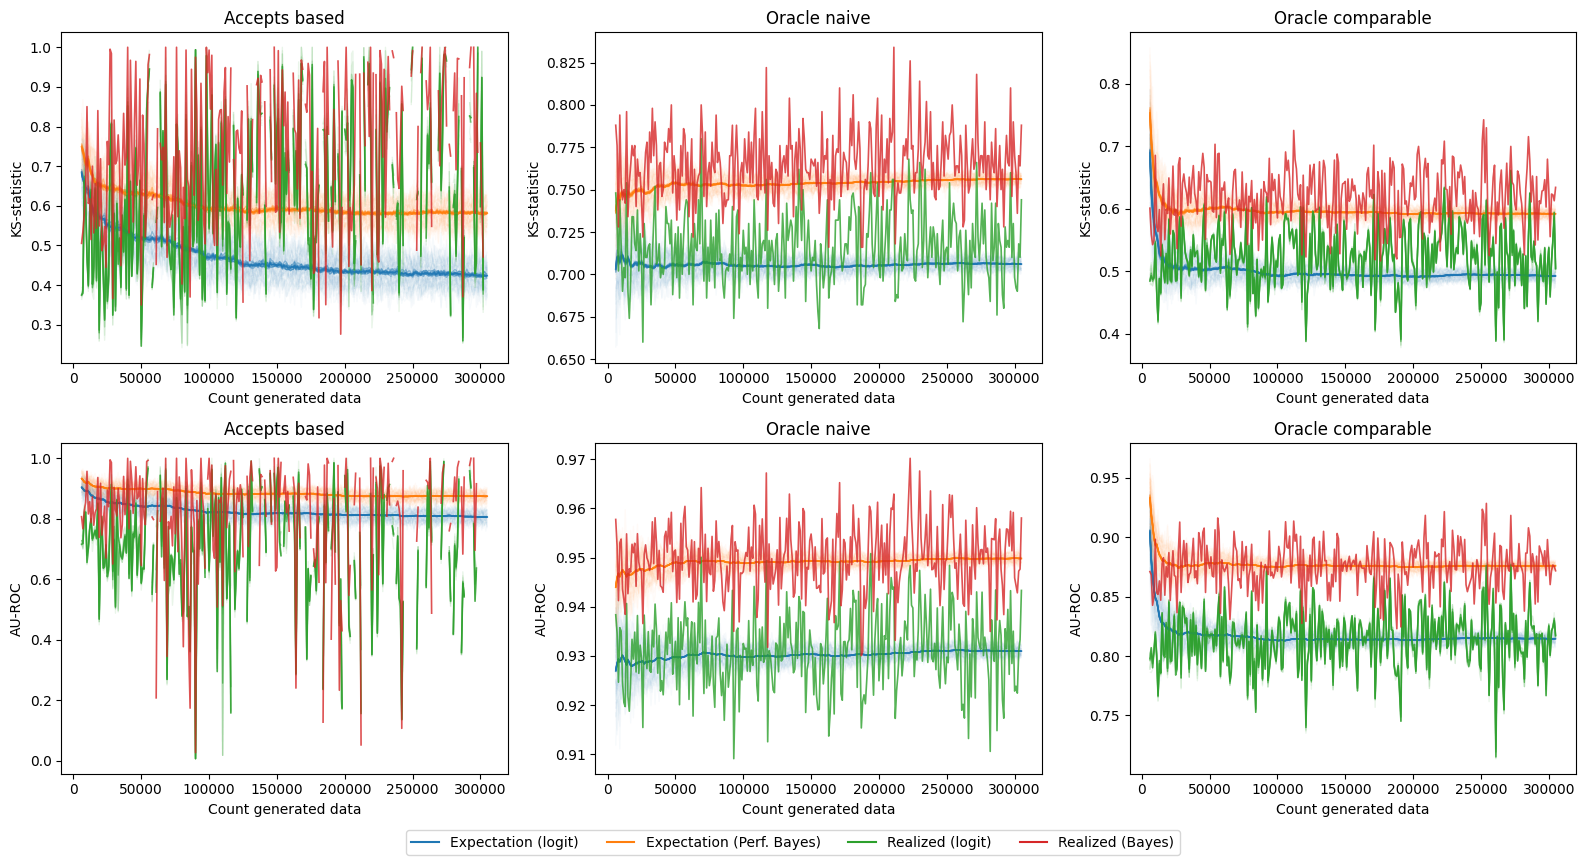

In [112]:
plot_lines_and_mains(
    generate_line_collections_for_exp_real_plot(base_sim_objs),
    sample_sizes=base_sim_objs["sample_sizes"],
    add_fig_legend=True,
    add_legend=False
)

In [ ]:
all_threshold_lbls = [t+'_'+m for m in METRIC_CATEGORIES for t in THRESHOLD_BASIS]
acc_flags = {k : v.clone for k, v in sim_objs['alternative_accepted'].items()}
lbl_acc_flag_in_data = set(all_threshold_lbls) - set(acc_flags.keys())
assert len(lbl_acc_flag_in_data) == 1
lbl_acc_flag_in_data = next(lbl_acc_flag_in_data.__iter__())
acc_flags[lbl_acc_flag_in_data] = sim_objs["credit_data"].accepted

In [98]:
credit_data = base_sim_objs["credit_data"]

credit_data.last_gen_round

tensor(300)

In [104]:
def get_acc_defaults_counts_per_round(sim_objs):
    all_threshold_lbls = [t+'_'+m for m in METRIC_CATEGORIES for t in THRESHOLD_BASIS]
    acc_flags: Dict[str, torch.Tensor] = {k : v.clone() for k, v in sim_objs['alternative_accepted'].items()}
    lbl_acc_flag_in_data = set(all_threshold_lbls) - set(acc_flags.keys())
    assert len(lbl_acc_flag_in_data) == 1
    lbl_acc_flag_in_data = next(lbl_acc_flag_in_data.__iter__())

    credit_data: CreditData = sim_objs["credit_data"]
    acc_flags[lbl_acc_flag_in_data] = credit_data.accepted.clone()

    rounds = credit_data.gen_round
    G = credit_data.last_gen_round + 1 # Count rounds

    boolean_def_flag = credit_data.default_flag.to(bool)

    return {
        k : v.new_zeros((G,), dtype=torch.int32).scatter_add_(
            dim=-1,
            index=rounds,
            src=(v & boolean_def_flag).to(torch.int32)
        )
        for k, v in acc_flags.items()
    }


get_acc_defaults_counts_per_round(base_sim_objs)

{'oracle_ks': tensor([227,  68,  60,  80,  65,  76,  81,  78,  76,  65,  97,  93,  80,  80,
          76,  78,  79,  67,  91,  65,  72,  94,  72,  79,  85,  71,  76,  80,
          70,  64,  61,  74,  73,  73,  73,  76,  70,  68,  68,  72,  65,  68,
          66,  76,  70,  80,  93,  75,  82,  73,  72,  74,  71,  64,  65,  78,
          81,  62,  80,  68,  72,  79,  59,  66,  62,  82,  80,  74,  91,  76,
          71,  74,  74,  72,  72,  75,  86,  70,  72,  78,  82,  88,  72,  86,
          73,  69,  84,  62,  89,  78,  70,  69,  80,  70,  89,  73,  84,  76,
          71,  76,  91,  75,  77,  63,  81,  77,  75,  66,  75,  69,  65,  65,
          64,  81,  70,  83,  67,  72,  87,  65,  74,  87,  78,  89,  72,  77,
          81,  69,  75,  69,  69,  62,  71,  68,  68,  78,  65,  74,  67,  63,
          74,  83,  66,  62,  75,  87,  71,  89,  84,  90,  81,  86,  71,  79,
          82,  76,  74,  69,  85,  70,  83,  76,  70,  68,  64,  67,  63,  79,
          83,  80,  72,  75,  80,  71, 

In [123]:
from typing import Optional
def calc_diffs(exp: torch.Tensor, real: torch.Tensor):

    diff_real = real - exp.mean(dim=(-1, -2))
    return diff_real


def generate_lines_for_diffs(
        sim_objs : Dict[str, torch.Tensor],
        add_real_bayes: bool = True
    ):
    only_related_exp: bool = True
    stats = sim_objs["stats"]
    bayes_stats = sim_objs["perf_bayes_stats"]

    exp_to_real_diffs_complete = {
        "sample_sizes" : sim_objs["sample_sizes"],
        "diff_data" : {}
    }

    mask_no_bads_among_acc = {
        k : v == 0 for k, v in get_acc_defaults_counts_per_round(sim_objs).items()
    }
    exp_to_real_diffs = exp_to_real_diffs_complete["diff_data"]

    for exp in EXPECTATION_TYPES:
        for m in METRIC_CATEGORIES:
            current_lbl = exp + '_' + m
            exp_to_real_diffs[current_lbl] = {
                "logit" : {
                    "diffs_cv" : None,
                    "diffs_real" : None
                }
            }
            if add_real_bayes:
                exp_to_real_diffs[current_lbl]["bayes"] = {
                    "diffs_cv" : None,
                    "diffs_real" : None
                }
            
                
            # 1. CV x K lines - plot all cv lines of the expectation
            exp_lbl = exp+'_'+m+'_stats'

            th_is_oracle = exp.startswith("oracle")
            th = "oracle" if th_is_oracle else exp
            assert th in THRESHOLD_BASIS, "Threshold logic changed"

            for perf in REAL_PERFORMANCE_TYPES:
                perf_is_unb_future = perf=="unbiased_future"
                should_add = False
                if exp == 'acc_based':
                    should_add = perf == "biased_acc"
                elif exp == 'oracle_naive':
                    should_add = perf == "unbiased_future"
                elif exp=='oracle_comparable':
                    should_add = perf == 'unbiased_acc'
                if perf_is_unb_future:
                    real_lbl_stats = perf+ '_' + th
                    if not th_is_oracle:
                        # If not oracle, the available history also depend on the basis
                        # of the threshold metric and can/should generate different
                        # scores which of course **do** affect the realized performance
                        real_lbl_stats += "_" + m # Make sure based on same metric for acc-based
                    real_lbl_stats += '_real_' + m
                    realized = stats[real_lbl_stats] # [gen]

                    # lines_real and colors_real are empty lists
                    if should_add:
                        exp_to_real_diffs[current_lbl]["logit"] = calc_diffs(stats[exp_lbl], realized)
                        #exp_to_real_diffs[exp_lbl] = calc_diffs(stats[exp_lbl], None, realized)
                    if should_add and add_real_bayes:
                        exp_to_real_diffs[current_lbl]["bayes"] = calc_diffs(bayes_stats[exp_lbl][:-1], bayes_stats[real_lbl_stats][1:])
                else:
                    # This branch is evaluation on accepts, either biased or unbiased
                    # therefore they are also dependent on the metric used as basis
                    # for the decision and it must be considered in the thresholding
                    # calculation - which was done -. `th + "_" + m` makes sure we
                    # get the realized performance on the right accepts
                    real_lbl_stats = perf+ '_' + th + "_" + m + '_real_' + m
                    realized_based_on_actual_accept_decision = stats[real_lbl_stats][:, -1] # [gen]
                    if not only_related_exp or should_add:
                        exp_to_real_diffs[current_lbl]["logit"] = calc_diffs(
                            stats[exp_lbl], realized_based_on_actual_accept_decision.masked_fill(
                                mask_no_bads_among_acc[th+'_'+m][1:], float('nan')
                            )
                        )
                    if should_add and add_real_bayes:
                        exp_to_real_diffs[current_lbl]["bayes"] = calc_diffs(
                            bayes_stats[exp_lbl][:-1], bayes_stats[real_lbl_stats][1:].masked_fill(
                                mask_no_bads_among_acc[th+'_'+m][1:], float('nan')
                            )
                        )

    return exp_to_real_diffs_complete

def gen_lines_from_diff_dict(exp_to_real_diffs, make_abs = False):
    _, _, colors = linetypes_labels_and_colors_for_exp_real_plot(
        only_related_exp=True
    )
    labels_linetypes = {"logit" : "Logit", "bayes" : "Perfect Bayes"}
    colors_for_diffs = {"logit" : colors["exp"], "bayes" : colors["exp_bayes"]}

    alpha_dict_real = {3: 0.1, 2: 0.6, 1 : 0.8}

    sample_sizes = exp_to_real_diffs["sample_sizes"]

    line_collections_data: Dict[str, Dict[str, List]] = {}

    for lbl, diff_data in exp_to_real_diffs["diff_data"].items():
        line_collections_data[lbl] = {
                "lines" : [],
                "colors" : [],
                "mains" : []
        }

        for model in ["logit", "bayes"]:
            stat_diffs = diff_data[model]
            if make_abs:
                stat_diffs = stat_diffs.abs()
            _, _, main_real = gen_lines_colors_and_main(
                stat=stat_diffs,
                sample_sizes=sample_sizes,
                base_color=colors_for_diffs[model],
                main_lbl=labels_linetypes[model],
                alpha_dict=alpha_dict_real
            )
            line_collections_data[lbl]["mains"].append(main_real)

    return line_collections_data
    

exp_to_real_diffs_base = generate_lines_for_diffs(base_sim_objs)

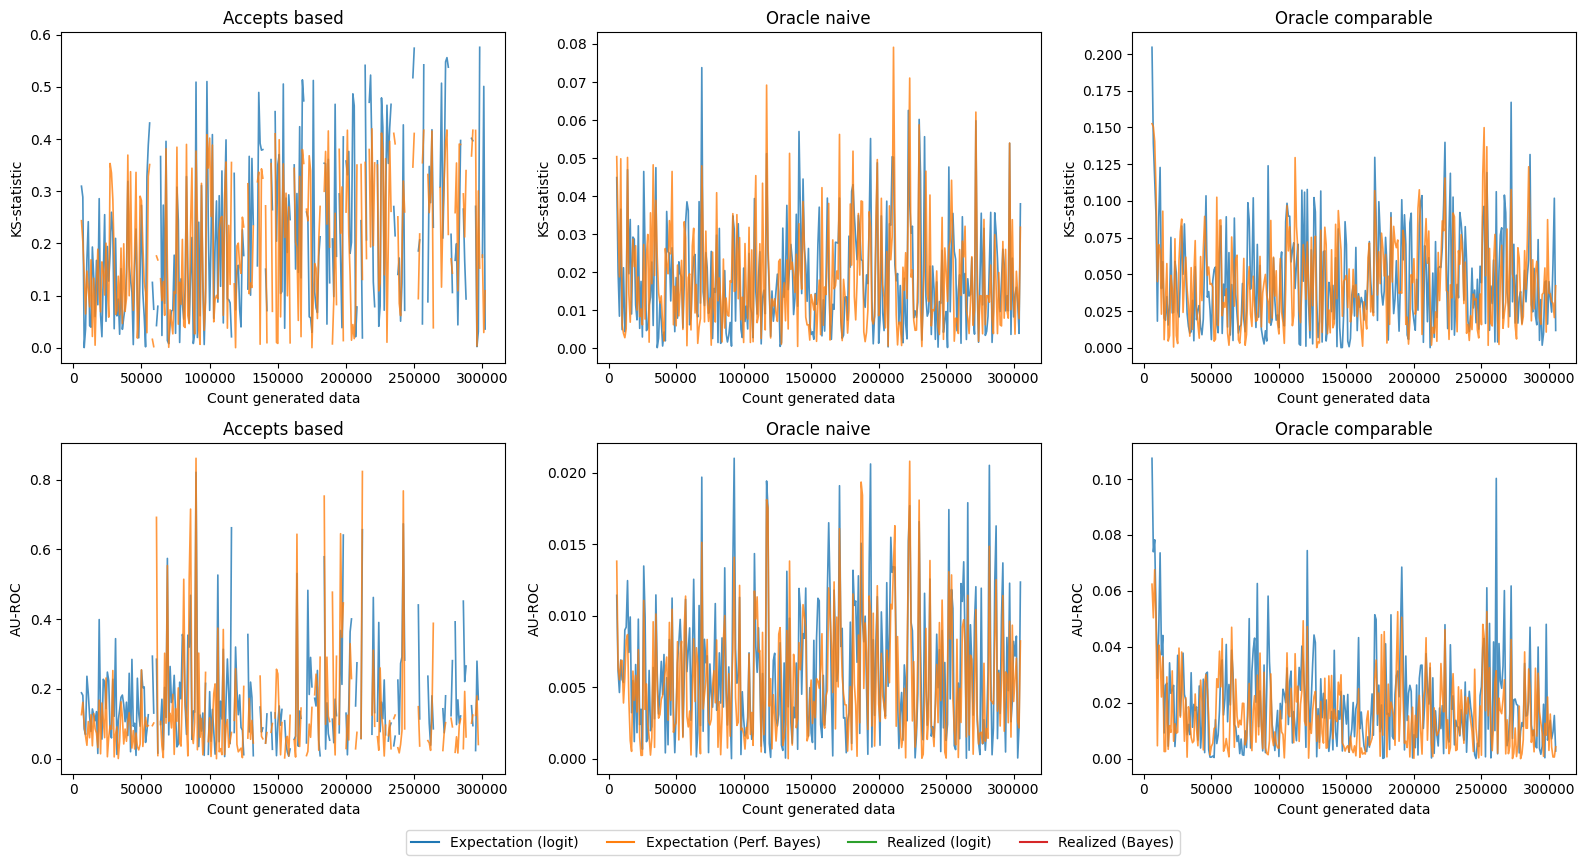

In [124]:
plot_lines_and_mains(
    gen_lines_from_diff_dict(exp_to_real_diffs_base, make_abs=True),
    sample_sizes=exp_to_real_diffs_base["sample_sizes"],
    add_fig_legend=True,
    add_legend=False
)

# 3D Part (still to check and do)

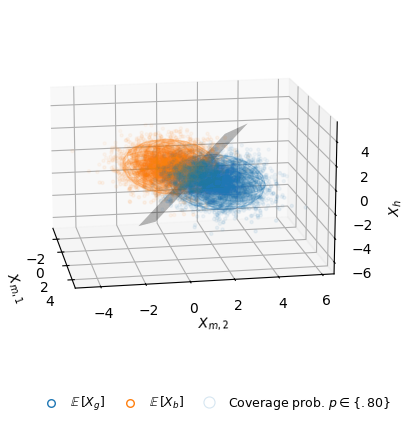

In [ ]:
from math import log

fig = plt.figure(figsize=(12,4.5))

ax = fig.add_subplot(1,1, 1, projection="3d")

dgp_base.plot_credit_dgp_3d(
    sample_size=10_000,
    axes=[ax], elev=15, azim=-10
)
#pos = ax.get_position()
ax.set_box_aspect((4, 5, 3))



# --- Compute LDA direction ---
w = inv_cov @ (mu_b - mu_g)   # shape (3,)

# --- Compute clean intercept w0 ---
pi = dgp_base.prob_bad_given_no_shock
w0 = -0.5 * (mu_b + mu_g) @ (inv_cov @ (mu_b - mu_g)) + log(pi / (1 - pi))

if dgp_base.simulate_idiosyncratic_shocks:
    # --- Compute noisy shift gamma ---
    pi_s = dgp_base.prob_idiosyncratic_shock
    pi_eps = dgp_base.prob_bad_given_shock
    c = 0.5 + (pi_eps / (1 - pi_eps)) * (0.5 - pi_s)
    gamma = torch.log(c / (1 - c))
else:
    gamma = 0

# --- Final intercept for noisy Bayes plane ---
b = w0 - gamma

# --- Create grid for plane ---
xx, yy = torch.meshgrid(
    torch.linspace(-2, 3, 30),
    torch.linspace(-1.2, 3, 30),
    indexing="xy"
)

# Solve for z: w1*x + w2*y + w3*z + b = 0
zz = (-b - w[0]*xx - w[1]*yy) / w[2]

# Convert to numpy for matplotlib
xx_np = xx.numpy()
yy_np = yy.numpy()
zz_np = zz.numpy()

# --- Plot the plane ---
ax.plot_surface(xx_np, yy_np, zz_np, alpha=0.3, color="black")


ax.set_xlabel("$X_{m, 1}$")
ax.set_ylabel("$X_{m, 2}$")
ax.set_zlabel("$X_{h}$")

pos = ax.get_position()
ax.set_position([pos.x0 - 0.1, pos.y0 - 0.05, pos.width + 0.12, pos.height])

#fig.tight_layout()

plt.show()

In [92]:
xx.shape

torch.Size([30, 30])

In [48]:
torch.linalg.inv(dgp_base.bad_mixture.cov), torch.cholesky_inverse(dgp_base.bad_mixture.cov_chol_decomp)

(tensor([[ 1.0417, -0.2083,  0.0000],
         [-0.2083,  1.0417,  0.0000],
         [ 0.0000,  0.0000,  1.0000]], dtype=torch.float64),
 tensor([[ 1.0417, -0.2083, -0.0000],
         [-0.2083,  1.0417, -0.0000],
         [-0.0000, -0.0000,  1.0000]], dtype=torch.float64))